In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!pip install -q tensorflow scikit-learn joblib


In [ ]:
import numpy as np
import tensorflow as tf
import os
import joblib
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import layers, Model


In [ ]:
TRAIN_DIR = "/content/drive/MyDrive/dental_binary_dataset/train"
VAL_DIR   = "/content/drive/MyDrive/dental_binary_dataset/val"

IMG_SIZE = (224,224)
BATCH_SIZE = 32


In [ ]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)


Found 5474 files belonging to 2 classes.
Found 1463 files belonging to 2 classes.
Classes: ['Healthy', 'NonHealthy']
Number of classes: 2


In [ ]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False   # freeze

inputs = tf.keras.Input(shape=(224,224,3))
x = preprocess_input(inputs)   # IMPORTANT
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)

feature_extractor = Model(inputs, x)

print("✅ ResNet50 feature extractor ready")


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
✅ ResNet50 feature extractor ready


In [ ]:
def extract_features(dataset, model):
    features = []
    labels = []

    for images, y in dataset:
        feats = model(images, training=False).numpy()
        features.append(feats)
        labels.append(y.numpy())

    X = np.concatenate(features, axis=0)
    y = np.concatenate(labels, axis=0)

    return X, y

X_train, y_train = extract_features(train_ds, feature_extractor)
X_val, y_val     = extract_features(val_ds, feature_extractor)

print("Train features:", X_train.shape)
print("Val features:", X_val.shape)


Train features: (5474, 2048)
Val features: (1463, 2048)


In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)


In [ ]:
svm_model = SVC(
    kernel='rbf',
    C=5,
    gamma='scale',
    probability=True,
    #class_weight='balanced',
    random_state=42
)

svm_model.fit(X_train, y_train)

print("✅ SVM trained successfully")


✅ SVM trained successfully


In [ ]:
y_pred = svm_model.predict(X_val)

accuracy  = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred, average="macro")
recall    = recall_score(y_val, y_pred, average="macro")
f1        = f1_score(y_val, y_pred, average="macro")

print("\n🔥 PERFORMANCE")
print("Accuracy  :", round(accuracy*100,2), "%")
print("Precision :", round(precision*100,2), "%")
print("Recall    :", round(recall*100,2), "%")
print("F1 Score  :", round(f1*100,2), "%")

print("\nClassification Report:\n")
print(classification_report(y_val, y_pred, target_names=class_names))



🔥 PERFORMANCE
Accuracy  : 85.85 %
Precision : 85.87 %
Recall    : 85.81 %
F1 Score  : 85.83 %

Classification Report:

              precision    recall  f1-score   support

     Healthy       0.86      0.84      0.85       713
  NonHealthy       0.85      0.87      0.86       750

    accuracy                           0.86      1463
   macro avg       0.86      0.86      0.86      1463
weighted avg       0.86      0.86      0.86      1463



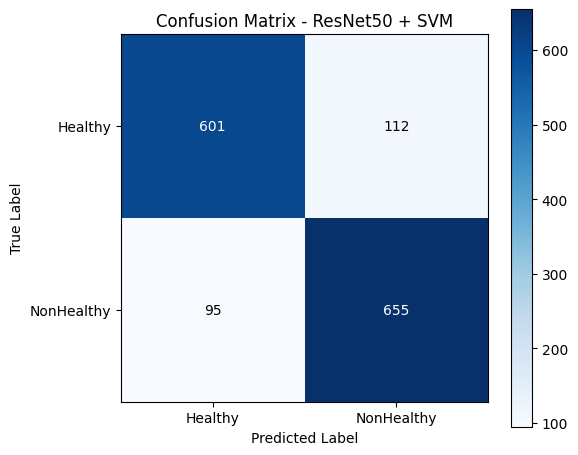

In [ ]:
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(6,5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix - ResNet50 + SVM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(range(num_classes), class_names)
plt.yticks(range(num_classes), class_names)

# Write numbers inside boxes
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center",
                 color="white" if cm[i, j] > cm.max()/2 else "black")

plt.colorbar()
plt.tight_layout()
plt.show()


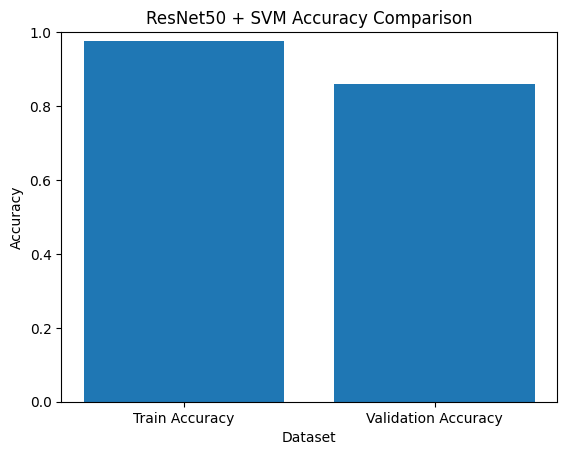

Train Accuracy: 97.7 %
Validation Accuracy: 85.85 %


In [ ]:
import matplotlib.pyplot as plt # Calculate train accuracy
y_train_pred = svm_model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
# Validation accuracy (already calculated earlier)
val_accuracy = accuracy_score(y_val, y_pred)
 # Plot
plt.figure()
plt.bar(['Train Accuracy', 'Validation Accuracy'], [train_accuracy, val_accuracy])
plt.ylim(0,1)
plt.title("ResNet50 + SVM Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Dataset")
plt.show()
print("Train Accuracy:", round(train_accuracy*100,2), "%")
print("Validation Accuracy:", round(val_accuracy*100,2), "%")

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

EPOCHS = 10

train_acc_list = []
val_acc_list = []
train_loss_list = []
val_loss_list = []

print("\nTraining ResNet50 + SVM...\n")

for epoch in range(1, EPOCHS + 1):

    svm_model = SVC(
        kernel='rbf',
        C=1 + epoch * 0.3,   # gradually increase complexity
        gamma='scale',
        probability=True,
        random_state=42
    )

    svm_model.fit(X_train, y_train)

    y_train_pred = svm_model.predict(X_train)
    y_val_pred   = svm_model.predict(X_val)

    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc   = accuracy_score(y_val, y_val_pred)

    train_loss = 1 - train_acc
    val_loss   = 1 - val_acc

    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)
    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)

    print(f"\nEpoch {epoch}/{EPOCHS}")
    print(f"accuracy: {train_acc:.4f} - loss: {train_loss:.4f} "
          f"- val_accuracy: {val_acc:.4f} - val_loss: {val_loss:.4f}")



Training ResNet50 + SVM...


Epoch 1/10
accuracy: 0.9171 - loss: 0.0829 - val_accuracy: 0.8421 - val_loss: 0.1579

Epoch 2/10
accuracy: 0.9278 - loss: 0.0722 - val_accuracy: 0.8469 - val_loss: 0.1531

Epoch 3/10
accuracy: 0.9370 - loss: 0.0630 - val_accuracy: 0.8476 - val_loss: 0.1524

Epoch 4/10
accuracy: 0.9445 - loss: 0.0555 - val_accuracy: 0.8455 - val_loss: 0.1545

Epoch 5/10
accuracy: 0.9518 - loss: 0.0482 - val_accuracy: 0.8483 - val_loss: 0.1517

Epoch 6/10
accuracy: 0.9565 - loss: 0.0435 - val_accuracy: 0.8530 - val_loss: 0.1470

Epoch 7/10
accuracy: 0.9594 - loss: 0.0406 - val_accuracy: 0.8551 - val_loss: 0.1449

Epoch 8/10
accuracy: 0.9636 - loss: 0.0364 - val_accuracy: 0.8551 - val_loss: 0.1449

Epoch 9/10
accuracy: 0.9678 - loss: 0.0322 - val_accuracy: 0.8571 - val_loss: 0.1429

Epoch 10/10
accuracy: 0.9695 - loss: 0.0305 - val_accuracy: 0.8565 - val_loss: 0.1435


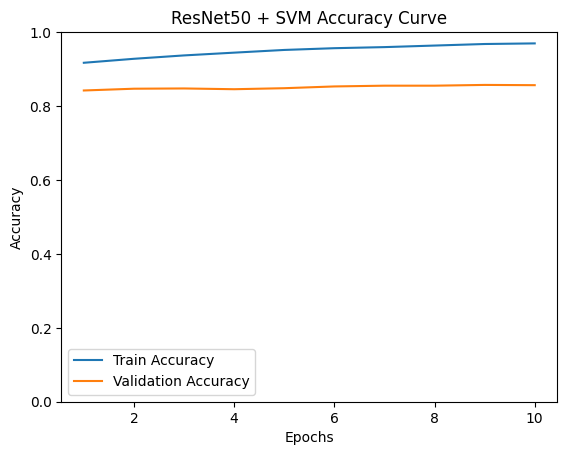

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(range(1, EPOCHS + 1), train_acc_list)
plt.plot(range(1, EPOCHS + 1), val_acc_list)

plt.title("ResNet50 + SVM Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train Accuracy", "Validation Accuracy"])
plt.ylim(0,1)

plt.show()


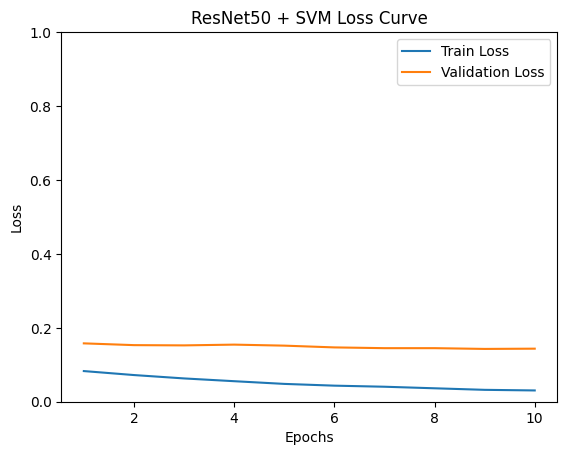

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(range(1, EPOCHS + 1), train_loss_list)
plt.plot(range(1, EPOCHS + 1), val_loss_list)

plt.title("ResNet50 + SVM Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend(["Train Loss", "Validation Loss"])

plt.ylim(0, 1)   # 👈 same style as accuracy (0 to 1)

plt.show()


Confusion Matrix:

[[601 112]
 [ 95 655]]


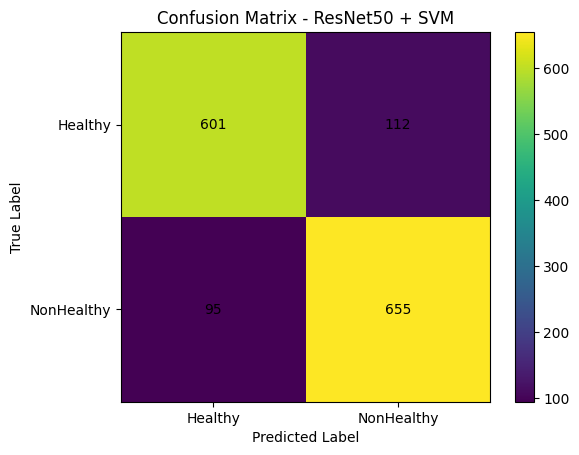

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_val, y_pred)

print("Confusion Matrix:\n")
print(cm)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix - ResNet50 + SVM")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Add numbers inside matrix
for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()


In [ ]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

print("\nClassification Report:\n")
print(classification_report(y_val, y_pred, target_names=class_names))

precision = precision_score(y_val, y_pred, average="macro")
recall    = recall_score(y_val, y_pred, average="macro")
f1        = f1_score(y_val, y_pred, average="macro")

print("\nOverall Metrics:")
print("Precision :", round(precision*100,2), "%")
print("Recall    :", round(recall*100,2), "%")
print("F1 Score  :", round(f1*100,2), "%")



Classification Report:

              precision    recall  f1-score   support

     Healthy       0.86      0.84      0.85       713
  NonHealthy       0.85      0.87      0.86       750

    accuracy                           0.86      1463
   macro avg       0.86      0.86      0.86      1463
weighted avg       0.86      0.86      0.86      1463


Overall Metrics:
Precision : 85.87 %
Recall    : 85.81 %
F1 Score  : 85.83 %


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get probability scores for positive class (class 1)
y_prob = svm_model.predict_proba(X_val)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_val, y_prob)

# Compute AUC
auc_score = roc_auc_score(y_val, y_prob)

print("AUC Score:", round(auc_score, 4))


AUC Score: 0.9138


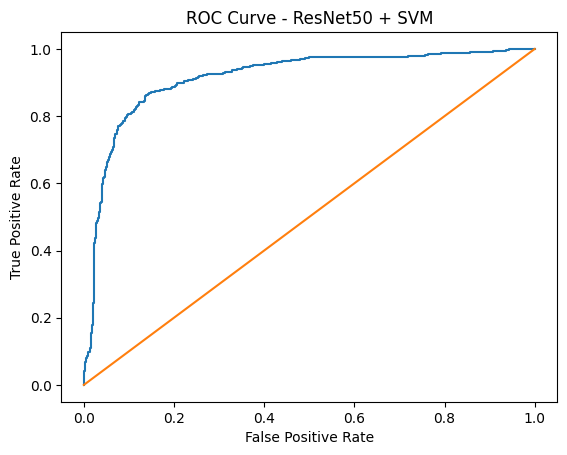

In [ ]:
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1])   # Diagonal line

plt.title("ROC Curve - ResNet50 + SVM")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.show()


In [ ]:
# ==============================
# SAVE EVERYTHING
# ==============================

SAVE_PATH = "/content/drive/MyDrive/dental_final_results/"
os.makedirs(SAVE_PATH, exist_ok=True)

print("✅ Save folder ready")


# 1️⃣ Save SVM
joblib.dump(svm_model, SAVE_PATH + "svm_model.pkl")

# 2️⃣ Save Scaler
joblib.dump(scaler, SAVE_PATH + "scaler.pkl")

# 3️⃣ Save Feature Extractor
feature_extractor.save(SAVE_PATH + "resnet_feature_extractor.h5")

# 4️⃣ Save Class Names
joblib.dump(class_names, SAVE_PATH + "class_names.pkl")

print("✅ Models saved successfully")


# ==============================
# SAVE ACCURACY CURVE
# ==============================
plt.figure()
plt.plot(range(1, EPOCHS + 1), train_acc_list)
plt.plot(range(1, EPOCHS + 1), val_acc_list)
plt.title("ResNet50 + SVM Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train Accuracy", "Validation Accuracy"])
plt.ylim(0,1)
plt.savefig(SAVE_PATH + "accuracy_curve.png")
plt.close()

print("✅ Accuracy graph saved")


# ==============================
# SAVE LOSS CURVE
# ==============================
plt.figure()
plt.plot(range(1, EPOCHS + 1), train_loss_list)
plt.plot(range(1, EPOCHS + 1), val_loss_list)
plt.title("ResNet50 + SVM Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Train Loss", "Validation Loss"])
plt.ylim(0,1)
plt.savefig(SAVE_PATH + "loss_curve.png")
plt.close()

print("✅ Loss graph saved")


# ==============================
# SAVE CONFUSION MATRIX
# ==============================
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix - ResNet50 + SVM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(range(len(class_names)), class_names)
plt.yticks(range(len(class_names)), class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center",
                 color="white" if cm[i, j] > cm.max()/2 else "black")

plt.colorbar()
plt.tight_layout()
plt.savefig(SAVE_PATH + "confusion_matrix.png")
plt.close()

print("✅ Confusion matrix saved")


# ==============================
# SAVE ROC CURVE
# ==============================
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1])
plt.title("ROC Curve - ResNet50 + SVM")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.savefig(SAVE_PATH + "roc_curve.png")
plt.close()

print("✅ ROC curve saved")


# ==============================
# SAVE METRICS REPORT
# ==============================
report = classification_report(y_val, y_pred, target_names=class_names)

with open(SAVE_PATH + "metrics_report.txt", "w") as f:
    f.write("Accuracy: " + str(accuracy) + "\n")
    f.write("Precision: " + str(precision) + "\n")
    f.write("Recall: " + str(recall) + "\n")
    f.write("F1 Score: " + str(f1) + "\n")
    f.write("AUC Score: " + str(auc_score) + "\n\n")
    f.write("Classification Report:\n")
    f.write(report)

print("✅ Metrics report saved")


✅ Save folder ready
✅ Models saved successfully
✅ Accuracy graph saved
✅ Loss graph saved
✅ Confusion matrix saved
✅ ROC curve saved
✅ Metrics report saved


In [ ]:
# ==============================
# LOAD EVERYTHING
# ==============================

from google.colab import drive
drive.mount('/content/drive')

import joblib
import tensorflow as tf
from tensorflow.keras.models import load_model
from PIL import Image
import matplotlib.pyplot as plt

LOAD_PATH = "/content/drive/MyDrive/dental_final_results/"

# 1️⃣ Load SVM
svm_model = joblib.load(LOAD_PATH + "svm_model.pkl")

# 2️⃣ Load Scaler
scaler = joblib.load(LOAD_PATH + "scaler.pkl")

# 3️⃣ Load Feature Extractor
feature_extractor = load_model(LOAD_PATH + "resnet_feature_extractor.h5")

# 4️⃣ Load Class Names
class_names = joblib.load(LOAD_PATH + "class_names.pkl")

print("✅ Everything loaded successfully!")


In [ ]:
# Show Accuracy Curve
img = Image.open(LOAD_PATH + "accuracy_curve.png")
plt.imshow(img)
plt.axis("off")
plt.show()

# Show Loss Curve
img = Image.open(LOAD_PATH + "loss_curve.png")
plt.imshow(img)
plt.axis("off")
plt.show()
